# Anomaly detection in time series

The core functionality of ``dtaianomaly`` is to offer a simple interface for time series anomaly detection. Below, we illustrate how anomalies can be detected in time series using ``dtaianomaly``.


In [9]:
from dtaianomaly.data import demonstration_time_series
from dtaianomaly.visualization import plot_time_series_colored_by_score, plot_time_series_anomalies, plot_anomaly_scores
from dtaianomaly.preprocessing import MovingAverage
from dtaianomaly.anomaly_detection import MatrixProfileDetector
from dtaianomaly.pipeline import Pipeline
from dtaianomaly.thresholding import FixedCutoffThreshold
from dtaianomaly.evaluation import Precision, Recall, FBeta, AreaUnderROC, AreaUnderPR, ThresholdMetric

## Load and plot the data

We will illustrate how to detect anomalies with ``dtaianomaly`` using the demonstration time series. This time series can easily be loaded using the ``demonstration_time_series`` method and then plotted using the ``plot_time_series_colored_by_score`` method.

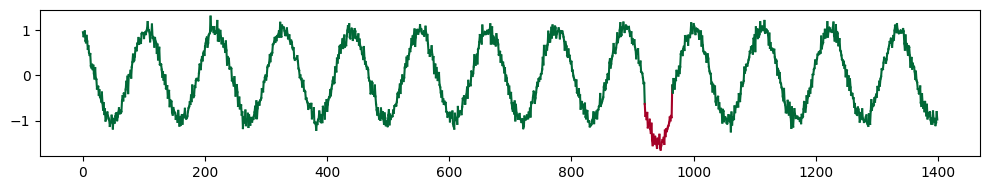

In [10]:
X, y = demonstration_time_series()
plot_time_series_colored_by_score(X, y, figsize=(10, 2)).tight_layout()

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [31]:


df= pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)
df.head(1)
ts = ['Consumption','Wind',	'Solar']
exog_cols = ['temperature','radiation_direct_horizontal']
y = df.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]



ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq


SEASON = 52

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

# plot_series_v2(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1', n_cols = 3)

In [34]:
for (uid, df_),(uid, train),(uid, test) in zip(panel_df.groupby("unique_id"),df_train.groupby("unique_id"),df_test.groupby("unique_id")):
    break

In [37]:
X  = df_['y'].values
y = np.zeros_like(X)

## Anomaly detection

Before detecting anomalies, we can preprocess the time series. In this case, we apply ``MovingAverage`` to remove some of the noise from the time series. 

In [38]:
preprocessor = MovingAverage(window_size=10)

In general, [any anomaly detector](https://dtaianomaly.readthedocs.io/en/stable/getting_started/anomaly_detection.html) in ``dtaianomaly`` can be used to detect anomalies in this time series. Here, we use the ``MatrixProfileDetector``.

In [53]:
detector = MatrixProfileDetector(window_size=SEASON//16)

Now that the components have been initialized, we can preprocess the time series and detect anomalies. Note that the preprocessor returns two values, processed data ``X_`` and processed ground truth ``y_``. While ``MovingAverage``] does not process the ground truth, other preprocessors may change the ground truth slightly. For example, ``SamplingRateUnderSampler`` samples both the time series ``X`` and labels ``y``. 

In [54]:
X_, y_ = preprocessor.fit_transform(X)
y_pred = detector.fit(X_).predict_proba(X_)

Below, we plot the time series again, as well as the predicted anomaly scores, and see that the predictions nicely align with the anomaly!

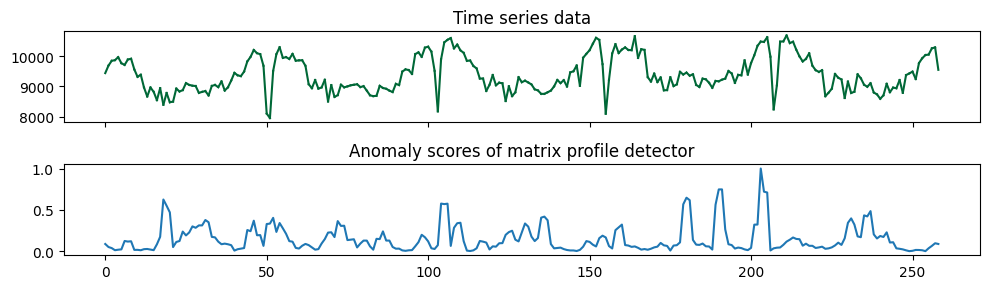

In [55]:
fig = plot_anomaly_scores(X, y, y_pred, method_to_plot=plot_time_series_colored_by_score, figsize=(10, 3))
fig.tight_layout()
fig.axes[1].set_title('Anomaly scores of matrix profile detector')
fig.savefig('Demonstration-time-series-detected-anomalies.svg')

Instead of directly analyzing time series predictions and thresholds manually, the `plot_time_series_anomalies` function provides an intuitive way to visualize anomalies in a time series. This function identifies True Positives (TP), False Positives (FP), and False Negatives (FN), and visualizes them on the time series. Below, we apply this function to the predicted anomaly scores on the demonstration time series. We apply ``FixedCutoffThreshold`` threshold for converting continuous scores into binary values.


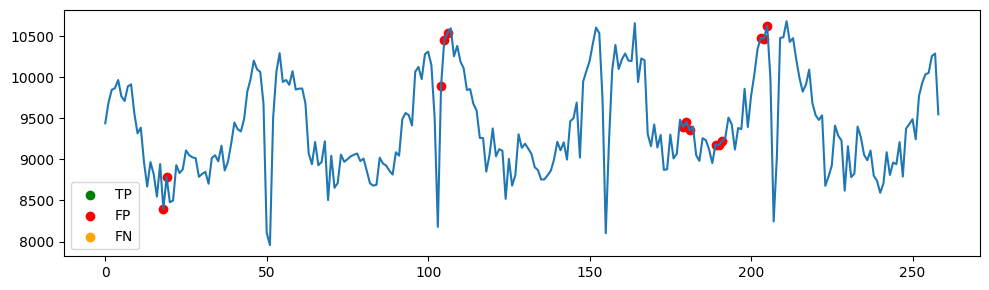

In [60]:
y_pred_binary = FixedCutoffThreshold(cutoff=0.5).threshold(y_pred)
plot_time_series_anomalies(X, y, y_pred_binary, figsize=(10, 3)).tight_layout()

## Anomaly detection with a Pipeline

Above, we manually preprocessed the data and detected anomalies within the processed data. In ``dtaianomaly``, these steps can be performed automatically using a ``Pipeline``. Upon initialization, we simply pass the preprocessors we want to apply, as well as the detector. The fit and predict methods will automatically process the data before detecting anomalies. Note that it is also possible to pass a list of preprocessors to apply multiple preprocessing steps before detecting anomalies.

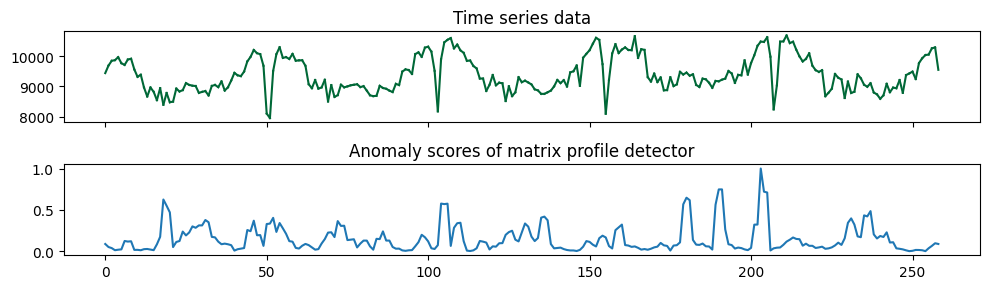

In [64]:
pipeline = Pipeline(
    preprocessor=preprocessor,
    detector=detector
)
y_pred = pipeline.fit(X).predict_proba(X)
fig = plot_anomaly_scores(X, y, y_pred, method_to_plot=plot_time_series_colored_by_score, figsize=(10, 3))
fig.tight_layout()
fig.axes[1].set_title('Anomaly scores of matrix profile detector')
fig.savefig('Demonstration-time-series-detected-anomalies.svg')

In [76]:
from dtaianomaly.data import PathDataLoader, DataSet
from dtaianomaly.preprocessing import Preprocessor
from dtaianomaly.anomaly_detection import IsolationForest, LocalOutlierFactor, MatrixProfileDetector
from dtaianomaly.pipeline import Pipeline
from dtaianomaly.thresholding import ContaminationRateThreshold
from dtaianomaly.evaluation import Precision, Recall, FBeta, AreaUnderROC
from dtaianomaly.workflow import Workflow

In [77]:
from dtaianomaly.anomaly_detection import IsolationForest, LocalOutlierFactor, MatrixProfileDetector

In [85]:
from dtaianomaly.data import DemonstrationTimeSeriesLoader
data_set = DemonstrationTimeSeriesLoader().load()
X = data_set.X_test
y = data_set.y_test

In [100]:
from dtaianomaly.data import CustomDataLoader, DataSet

# 1. Создаем класс загрузчика для ОДНОЙ колонки (одного uid)
class SingleSeriesLoader(CustomDataLoader):
    def __init__(self, df, column_name):
        self.df = df
        self.column_name = column_name

    def load(self):
        # Берем только одну колонку и делаем reshape, чтобы получить 2D массив (n_samples, 1)
        X = self.df[[self.column_name]].values
        return DataSet(X=X, y=None)

# 2. Создаем список загрузчиков для каждого 'uid' (колонки)
ts_columns = ['Consumption', 'Wind', 'Solar']

loaders = []
for col in ts_columns:
    # Для каждого ряда создаем свой загрузчик
    loader = SingleSeriesLoader(df=y, column_name=col)
    loaders.append(loader)



# 3. Запускаем Workflow
from dtaianomaly.workflow import Workflow
from dtaianomaly.anomaly_detection import IsolationForest
from dtaianomaly.evaluation import Precision, Recall

# Workflow автоматически пройдется по каждому загрузчику
workflow = Workflow(
    dataloaders=loaders,  # Передаем список
    detectors=[IsolationForest(15)],
    # metrics=[Precision(), Recall()]
)
workflow.run()
# results = workflow.run()
# Результаты будут содержать оценки для каждого ряда отдельно

TypeError: Workflow.__init__() missing 1 required positional argument: 'metrics'

In [108]:
import aeon

In [107]:
import sys

sys.path.insert(0, "..")

import pandas as pd
import seaborn as sns

sns.set_theme()
sns.set_color_codes()

from sktime.datasets import load_electric_devices_segmentation
from sktime.detection.clasp import ClaSPSegmentation, find_dominant_window_sizes
from sktime.detection.plotting.utils import (
    plot_time_series_with_change_points,
    plot_time_series_with_profiles,
)

ImportError: cannot import name '_check_estimator_deps' from 'skbase.utils.dependencies' (C:\Users\Ronkin\AppData\Roaming\Python\Python311\site-packages\skbase\utils\dependencies\__init__.py)

In [106]:
workflow = Workflow(
    dataloaders = loaders,
    detectors=[
        IsolationForest(15),
        LocalOutlierFactor(15),
        MatrixProfileDetector(window_size=12)  # подберите под ваш SEASON=52
    ],
    thresholds = ContaminationRateThreshold(0.1),
    metrics=[Precision(), Recall(), FBeta(beta=1.0), AreaUnderROC()]
)

# Запуск workflow
results = workflow.run()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [96]:
thresholds = ContaminationRateThreshold(0.1)
metrics = [Precision(), Recall(), FBeta(beta=1), AreaUnderROC()]
detectors = [
    IsolationForest(window_size=15),
    LocalOutlierFactor(window_size=15),
    MatrixProfileDetector(window_size=15)
]

In [97]:
workflow = Workflow(
    dataloaders=loaders,
    detectors=detectors,
    metrics=metrics,
    thresholds=thresholds
)
workflow.run()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [78]:
detectors = [
    IsolationForest(window_size=15),
    LocalOutlierFactor(window_size=15),
    MatrixProfileDetector(window_size=15)
]

In [79]:
thresholds = ContaminationRateThreshold(0.1)
metrics = [Precision(), Recall(), FBeta(beta=1), AreaUnderROC()]

In [81]:
from dtaianomaly.data import LazyDataLoader

In [84]:
train_loader = PathDataLoader("OPDS_DE_EDA.csv")
train_set = train_loader

TypeError: Can't instantiate abstract class PathDataLoader with abstract method _load

In [ ]:
workflow = Workflow(
    dataloaders=dataloaders,
    preprocessors=preprocessors,
    detectors=detectors,
    metrics=metrics,
    thresholds=thresholds
)
workflow.run()

## Quantitative evaluation

Besides visually checking the performance of an anomaly detector, it is also important to quantitatively measure how accurately the anomalies are detected. Below, we first compute the ``Precision`` and ``Recall``. However, that the precision and recall require binary labels, while the predicted anomaly scores are continuous. For this reason, we apply ``FixedCutoffThreshold`` thresholding to convert all scores above 0.85 to 1 ("anomaly") and the scores below 0.85 to 0 ("normal"). At this threshold, we see that all anomalous observations are detected (recall=1.0), at the cost of some false positives near the borders of the ground truth anomaly (precision<1).

In [65]:
thresholding = FixedCutoffThreshold(0.5)
y_pred_binary = thresholding.threshold(y_pred)
print('Precision:', Precision().compute(y, y_pred_binary))
print('Recall:', Recall().compute(y, y_pred_binary))

Precision: 0.0
Recall: 0.0


C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Alternatively to manually applying a threshold to convert the continuous scores to binary predictions, you can initialize a ``ThresholdMetric``, which will automatically apply a specified thresholding strategy before using a binary evaluation metric. Below, we use the same thresholding as above, but compute the ``FBeta`` score with $\beta=1$. 

In [66]:
print('F1:', ThresholdMetric(thresholding, FBeta(1.0)).compute(y, y_pred))

F1: 0.0


C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Lastly, we also compute the ``AreaUnderROC`` and ``AreaUnderPR``. Because these metrics create a curve for all possible thresholds, we can simply pass the predicted, continuous anomaly scores, as shown below. 

In [67]:
print('AUC-ROC:', AreaUnderROC().compute(y, y_pred))
print('AUC-PR:', AreaUnderPR().compute(y, y_pred))

AUC-ROC: nan
AUC-PR: 0.5


C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\Ronkin\anaconda3\envs\py311\Lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
